# Previsão e Avaliação de Performance - Versão Final

Este notebook integra as descobertas da análise exploratória (`relatorio.ipynb`) com o pipeline de cross-validation (`previsao_performance.ipynb`) para criar uma comparação mais robusta entre os modelos TSLM, ARIMAX e Naive, incluindo métricas de avaliação probabilística e intervalos de previsão.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from abc import ABC, abstractmethod
from scipy.stats import norm
from utils import ForecastingStrategy, MetricStrategy

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## 1. Classes de Estratégia e Validação

In [ ]:
class NaiveModel(ForecastingStrategy):
    def __init__(self):
        self.last_value = None
        self._name = "Naive Baseline"
        # Desvio padrão
        self.sigma = 0

    def fit(self, y_train, X_train=None):
        # Deixando o último como previsão para todos
        self.last_value = y_train.iloc[-1]
        # Sigma para o erro padrão
        self.sigma = y_train.diff().std()

    def predict(self, steps, X_future=None):
        # fazendo a previsão para o resto
        forecast = np.array([self.last_value] * steps)
        # Desvio padrão
        sigmas = self.sigma * np.sqrt(np.arange(1, steps + 1))
        return forecast, sigmas

    @property
    def name(self):
        return self._name

In [ ]:
class TSLM(ForecastingStrategy):
    def __init__(self, model_name, feature_cols):
        self._name = model_name
        self.feature_cols = feature_cols
        self.model_fit = None

    def fit(self, y_train, X_train=None):
        # Adicionando as colunas no X
        X = sm.add_constant(X_train[self.feature_cols])
        # Ajustando uma OLS
        self.model_fit = sm.OLS(y_train, X).fit()

    def predict(self, steps, X_future=None):
        # Deixando o dataset correto para a predição
        X_pred = X_future[self.feature_cols].copy()
        X_pred['const'] = 1.0
        X_pred_ordered = X_pred[self.model_fit.model.exog_names]
        
        # Fazendo as previsões
        pred_results = self.model_fit.get_prediction(X_pred_ordered)
        pred_summary = pred_results.summary_frame(alpha=0.05)
        
        # Pegando a previsão pontual e o intervalo de confiança
        point_forecast = pred_summary['mean'].values
        sigmas = pred_summary['mean_se'].values
        
        return point_forecast, sigmas

    @property
    def name(self):
        return self._name

In [ ]:
class ARIMAX(ForecastingStrategy):
    def __init__(self, order, seasonal_order=(0,0,0,0)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.model_fit = None
        self._name = f"ARIMAX {order}"

    def fit(self, y_train, X_train=None):
        # Utilizanso SARIMAX, tirando a parte seasonal, para ficar como um ARIMAX
        model = SARIMAX(y_train, exog=X_train, order=self.order, 
                        seasonal_order=self.seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
        # Fitando
        self.model_fit = model.fit(disp=False)

    def predict(self, steps, X_future=None):
        # Fazendo a previsão
        forecast_obj = self.model_fit.get_forecast(steps=steps, exog=X_future)
        # Pegando a pontual e os erros
        point_forecast = forecast_obj.predicted_mean.values
        sigmas = forecast_obj.se_mean.values
        return point_forecast, sigmas

    @property
    def name(self):
        return self._name

In [ ]:
class TimeSeriesCrossValidator:
    """
    Classe que realizar a Time Series
    """
    def __init__(self, df, target_col, exog_cols, log_transform_target=False):
        self.df = df
        self.target_col = target_col
        self.exog_cols = exog_cols
        self.log_transform_target = log_transform_target

    def _prepare_future_exog(self, train_exog, steps):
        "Função para preparar os dados que iremos utilizar"
        if self.exog_cols is None: 
            return None
        # Repentindo os dados externos do último ponto que temos
        last_values = train_exog.iloc[-1]
        future_df = pd.DataFrame([last_values] * steps)
        
        if 'trend' in future_df.columns:
            future_df['trend'] = np.arange(last_values['trend'] + 1, last_values['trend'] + 1 + steps)
        return future_df

    def validate(self, strategy: ForecastingStrategy, steps_ahead=4, min_train_size=40, alpha=0.05):
        n = len(self.df)
        results = []
        # Valor crítico
        z_score = norm.ppf(1 - alpha / 2)

        # Deixamos um mínimo de dados para o modelo aprender algo e não simplesmente fitar qualquer ruido
        for i in range(min_train_size, n - steps_ahead + 1):
            # Selecionamso os valores até onde temos
            train = self.df.iloc[:i]
            # O teste com os steps a frente
            test_future = self.df.iloc[i : i + steps_ahead]
            
            # Selecionamos o y (o que queremos prever) e o X
            y_train = train[self.target_col]
            # As variaveis que utilizamos
            X_train = train[self.exog_cols] if self.exog_cols else None
            X_future = self._prepare_future_exog(X_train, steps_ahead)
            if X_future is not None: X_future.index = test_future.index

            # fitamso o ytrain com o log
            y_train_fit = np.log1p(y_train) if self.log_transform_target else y_train
            
            strategy.fit(y_train_fit, X_train)
            preds_transf, sigmas_transf = strategy.predict(steps_ahead, X_future)

            # Dependendo se aplicamos ou não precisamos voltar as previsões
            if self.log_transform_target:
                final_preds = np.expm1(preds_transf)
                lower_bounds = np.expm1(preds_transf - z_score * sigmas_transf)
                upper_bounds = np.expm1(preds_transf + z_score * sigmas_transf)
                sigmas_final = (upper_bounds - lower_bounds) / (2 * z_score)
            else:
                final_preds = preds_transf
                sigmas_final = sigmas_transf
                lower_bounds = final_preds - z_score * sigmas_final
                upper_bounds = final_preds + z_score * sigmas_final

            # Salvamos em steps ahead.
            for h in range(steps_ahead):
                results.append({
                    'cutoff_date': train.index[-1],
                    'target_date': test_future.index[h],
                    'horizon': h + 1,
                    'model': strategy.name,
                    'prediction': final_preds[h],
                    'actual': test_future[self.target_col].iloc[h],
                    'sigma': sigmas_final[h],
                    'lower_bound': lower_bounds[h],
                    'upper_bound': upper_bounds[h]
                })
        return pd.DataFrame(results)

## 2. Métricas de Avaliação e Visualização

Utilizaremos os mesmos da A1 para avaliar os modelos no intervalo de confiança

In [7]:
def winkler_score(y_true, lower, upper, alpha):
    score = np.where(
        y_true < lower,
        (upper - lower) + (2 / alpha) * (lower - y_true),
        np.where(y_true > upper, (upper - lower) + (2 / alpha) * (y_true - upper), (upper - lower))
    )
    return np.mean(score)

def quantile_score(y_true, quantile_forecast, p):
    error = y_true - quantile_forecast
    return np.mean(np.where(error >= 0, p * error, (p - 1) * error))

def crps_gaussian(y_true, mu, sigma):
    sigma = np.where(sigma < 1e-6, 1e-6, sigma)
    z = (y_true - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return np.mean(crps)

## Erros como uma metric strategy

In [ ]:
class RMSE(MetricStrategy):
    def calculate(self, group): 
        return np.sqrt(np.mean((group['prediction'] - group['actual'])**2))
    @property
    def name(self): 
        return "RMSE"

class MAE(MetricStrategy):
    def calculate(self, group): 
        return np.mean(np.abs(group['prediction'] - group['actual']))
    @property
    def name(self): 
        return "MAE"

class WinklerScore(MetricStrategy):
    def __init__(self, alpha=0.05): 
        self.alpha = alpha
    def calculate(self, group): 
        return winkler_score(group['actual'], group['lower_bound'], group['upper_bound'], self.alpha)
    @property
    def name(self): 
        return f"Winkler Score (a={self.alpha})"

class CRPS(MetricStrategy):
    def calculate(self, group): 
        return crps_gaussian(group['actual'], group['prediction'], group['sigma'])
    @property
    def name(self): 
        return "CRPS"

class AvgQuantileScore(MetricStrategy):
    def __init__(self, quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)): 
        self.quantiles = quantiles
    def calculate(self, group):
        scores = []
        for p in self.quantiles:
            q_forecast = norm.ppf(p, loc=group['prediction'], scale=group['sigma'])
            scores.append(quantile_score(group['actual'], q_forecast, p))
        return np.mean(scores)
    @property
    def name(self): 
        return "Avg Quantile Score"

## Metric evaluator para calcular todas as métricas

In [ ]:
class MetricsEvaluator:
    def __init__(self):
        self.metrics = []
    
    def add_metric(self, metric: MetricStrategy):
        self.metrics.append(metric)
        # permite o concatenamento.
        return self
        
    def evaluate(self, results_list):
        consolidated_data = []
        all_results = pd.concat(results_list, ignore_index=True)

        # Avaliação por horizonte
        for (model_name, horizon), group in all_results.groupby(['model', 'horizon']):
            row = {'Model': model_name, 'Horizon': horizon}
            for metric in self.metrics:
                row[metric.name] = metric.calculate(group)
            consolidated_data.append(row)
        
        # Avaliação geral (agregando todos os horizontes)
        for model_name, group in all_results.groupby('model'):
            row = {'Model': model_name, 'Horizon': 'Geral'}
            for metric in self.metrics:
                row[metric.name] = metric.calculate(group)
            consolidated_data.append(row)
                
        return pd.DataFrame(consolidated_data).sort_values(by=['Model', 'Horizon'])

In [10]:
class ResultsVisualizer:
    @staticmethod
    def plot_metric_comparison(metrics_df, metric_name):
        plt.figure(figsize=(12, 7))
        sns.barplot(data=metrics_df, x='Horizon', y=metric_name, hue='Model', palette='viridis')
        plt.title(f"Comparação de Performance: {metric_name}", fontsize=16)
        plt.ylabel(metric_name, fontsize=12)
        plt.xlabel("Horizonte de Previsão", fontsize=12)
        plt.grid(True, alpha=0.3, axis='y')
        plt.legend(title='Modelo', fontsize=11)
        plt.show()

    @staticmethod
    def plot_spaghetti_with_intervals(results_df, real_data_df, target_col):
        model_name = results_df['model'].iloc[0]
        colors = {'ARIMAX (1, 0, 0)': '#ff7f0e', 'TSLM (Log-Log)': '#2ca02c', 'Naive Baseline': '#1f77b4'}
        model_color = colors.get(model_name, 'blue')

        plt.figure(figsize=(14, 7))
        
        # Plot de todas as janelas de previsão com transparência
        for i, cutoff in enumerate(results_df['cutoff_date'].unique()):
            window_results = results_df[results_df['cutoff_date'] == cutoff]
            line_label = f'Previsão {model_name}' if i == 0 else None
            interval_label = 'Intervalo de Previsão 95%' if i == 0 else None
            
            plt.plot(window_results['target_date'], window_results['prediction'], linestyle='--', color=model_color, alpha=0.4, label=line_label)
            plt.fill_between(
                window_results['target_date'],
                window_results['lower_bound'],
                window_results['upper_bound'],
                color=model_color, alpha=0.05, label=interval_label
            )
        
        # Plot dos dados reais por cima
        plt.plot(real_data_df.index, real_data_df[target_col], label='Dados Reais', color='black', linewidth=2.5, marker='o', markersize=3, alpha=0.8)
        
        plt.title(f'Previsões (Espaguete) vs. Real com Intervalos - {model_name}', fontsize=16)
        plt.xlabel('Semana')
        plt.ylabel('Volume')
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='upper left')
        plt.grid(False)
        plt.show()

## 3. Preparação dos Dados

In [11]:
df_raw = pd.read_csv('data_updated.csv')
df_raw['week'] = pd.to_datetime(df_raw['week'])
df_raw = df_raw.set_index('week').sort_index().asfreq('W-MON')

df_features = df_raw.copy()
df_features['inv_lag1'] = df_features['inv'].shift(1)
df_features['users_lag1'] = df_features['users'].shift(1)
df_features['users_lag8'] = df_features['users'].shift(8)

df_features['log_inv_lag1'] = np.log1p(df_features['inv_lag1'])
df_features['log_users_lag1'] = np.log1p(df_features['users_lag1'])
df_features['log_users_lag8'] = np.log1p(df_features['users_lag8'])

df_features['trend'] = np.arange(len(df_features))
df_processed = df_features.dropna()

print("Dimensão do dataframe processado:", df_processed.shape)
df_processed.head()

Dimensão do dataframe processado: (149, 10)


,volume,inv,users,inv_lag1,users_lag1,users_lag8,log_inv_lag1,log_users_lag1,log_users_lag8,trend
week,,,,,,,,,,
2022-12-26,0.39,0.182695,0.778,0.182806,0.655,6.500,0.167889,0.503801,2.014903,8
2023-01-02,0.33,0.121898,0.808,0.182695,0.778,7.061,0.167795,0.575489,2.087038,9
2023-01-09,0.36,0.361241,1.641,0.121898,0.808,5.875,0.115022,0.592221,1.927892,10
2023-01-16,0.49,0.448260,2.323,0.361241,1.641,24.238,0.308397,0.971158,3.228351,11
2023-01-23,0.50,0.509576,2.137,0.448260,2.323,7.648,0.370363,1.200868,2.157328,12


## 4. Execução e Avaliação dos Modelos

In [ ]:
TARGET_COL = 'volume'
EXOG_COLS = ['log_inv_lag1', 'log_users_lag1', 'log_users_lag8', 'trend']

validator = TimeSeriesCrossValidator(
    df=df_processed, 
    target_col=TARGET_COL, 
    exog_cols=EXOG_COLS, 
    log_transform_target=True
)

strategy_naive = NaiveModel()
strategy_tslm = TSLM(model_name='TSLM (Log-Log)', feature_cols=EXOG_COLS)
strategy_arimax = ARIMAX(order=(1, 0, 0))

results_naive = validator.validate(strategy_naive, min_train_size=40)
results_tslm = validator.validate(strategy_tslm, min_train_size=40)
results_arimax = validator.validate(strategy_arimax, min_train_size=40)

evaluator = MetricsEvaluator()
evaluator.add_metric(RMSE()).add_metric(MAE())
evaluator.add_metric(WinklerScore()).add_metric(CRPS()).add_metric(AvgQuantileScore())

all_results = [results_naive, results_tslm, results_arimax]
df_metrics = evaluator.evaluate(all_results)

print("\nResultados da Avaliação por Horizonte:")
pd.set_option('display.max_columns', None)
display(df_metrics[df_metrics['Horizon'] != 'Geral'].pivot(index='Horizon', columns='Model'))
print("\nResultados Gerais (agregando todos os horizontes):")
display(df_metrics[df_metrics['Horizon'] == 'Geral'].set_index('Model').drop('Horizon', axis=1))

--- Iniciando Validação: Naive Baseline ---


--- Iniciando Validação: TSLM (Log-Log) ---


--- Iniciando Validação: ARIMAX (1, 0, 0) ---


C:\Users\kauan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kauan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\kauan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

C:\Users\kauan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Resultados da Avaliação por Horizonte:


RMSE                                            MAE  \
Model   ARIMAX (1, 0, 0) Naive Baseline TSLM (Log-Log) ARIMAX (1, 0, 0)   
Horizon                                                                   
1               1.336215       1.355063       1.801597         0.900879   
2               1.727943       1.771870       1.905809         1.227341   
3               1.974424       2.022270       2.112658         1.438970   
4               2.066829       2.123585       2.182385         1.479730   

                                      Winkler Score (a=0.05)                 \
Model   Naive Baseline TSLM (Log-Log)       ARIMAX (1, 0, 0) Naive Baseline   
Horizon                                                                       
1             0.903774       1.134827               7.460501       6.215690   
2             1.252547       1.239287              10.656512       8.503136   
3             1.477264       1.341630              11.267007       9.306360   
4             1.501509       1.495324              12.353710      10.808989   

                                   CRPS                                \
Model   TSLM (Log-Log) ARIMAX (1, 0, 0) Naive Baseline TSLM (Log-Log)   
Horizon                                                                 
1            31.137245         0.655705       0.649264       1.024875   
2            34.365537         0.904047       0.904252       1.122141   
3            38.047582         1.040427       1.044484       1.222723   
4            43.753096         1.100828       1.111969       1.372739   

        Avg Quantile Score                                
Model     ARIMAX (1, 0, 0) Naive Baseline TSLM (Log-Log)  
Horizon                                                   
1                 0.324054       0.320281       0.513348  
2                 0.444466       0.444294       0.561992  
3                 0.510963       0.512745       0.612450  
4                 0.546786       0.550259       0.688006


Resultados Gerais (agregando todos os horizontes):


,RMSE,MAE,Winkler Score (a=0.05),CRPS,Avg Quantile Score
Model,,,,,
"ARIMAX (1, 0, 0)",1.798707,1.261730,10.434432,0.925252,0.456567
Naive Baseline,1.842207,1.283774,8.708544,0.927492,0.456895
TSLM (Log-Log),2.006489,1.302767,36.825865,1.185619,0.593949


## 5. Visualização dos Resultados

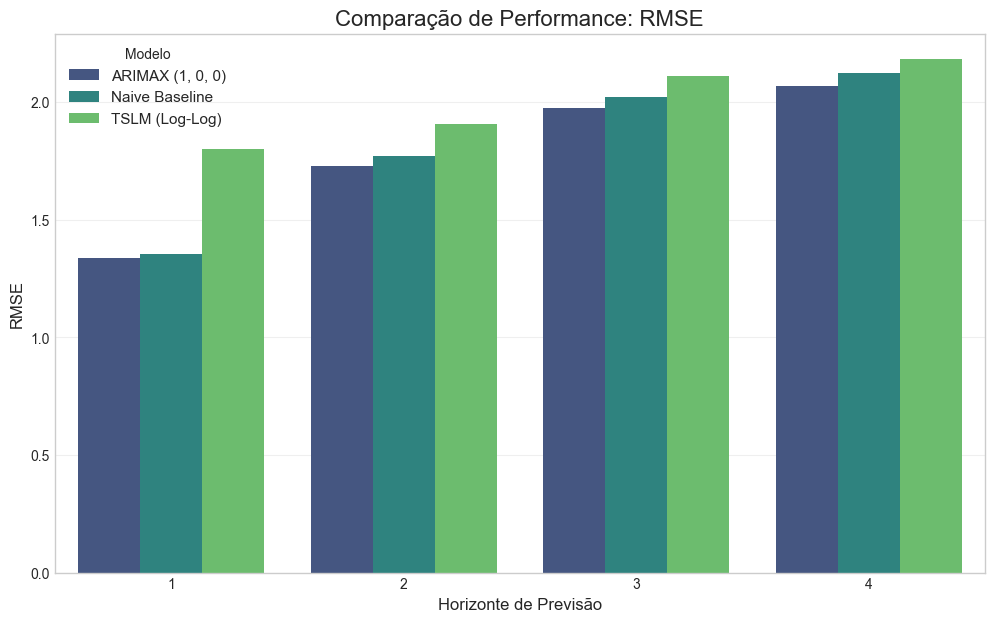

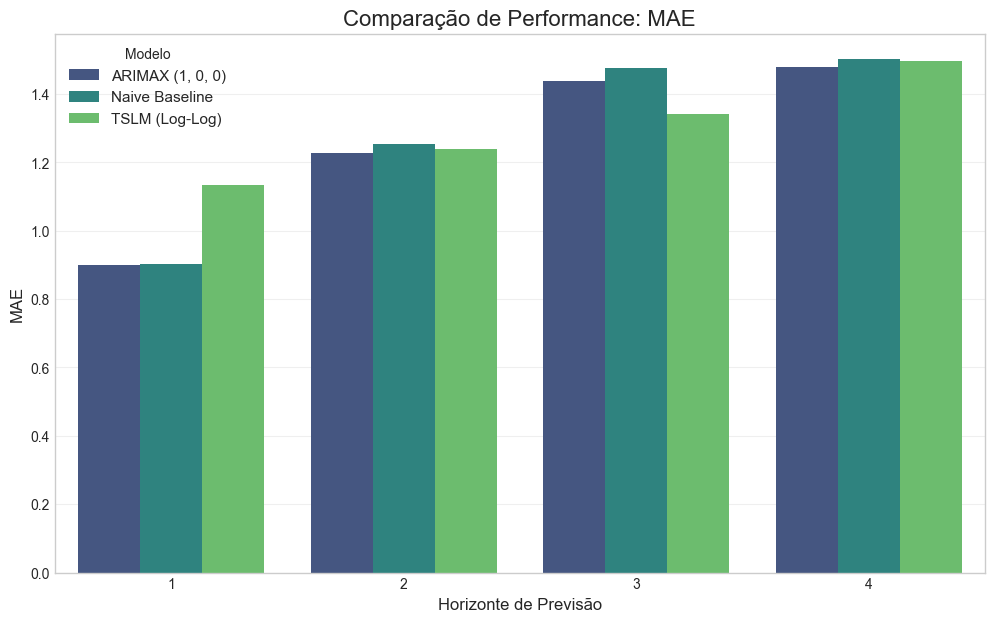

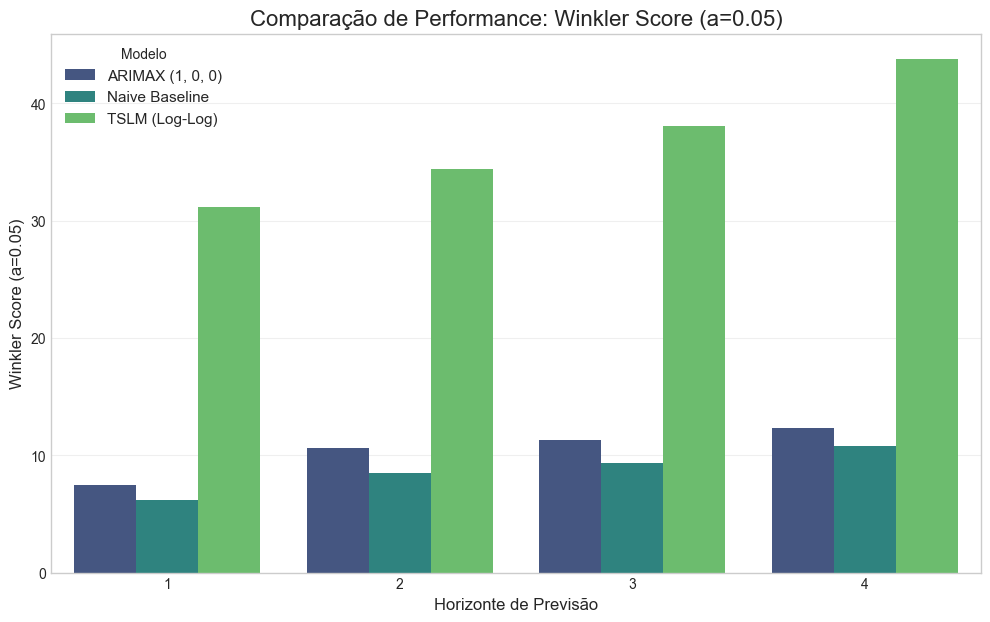

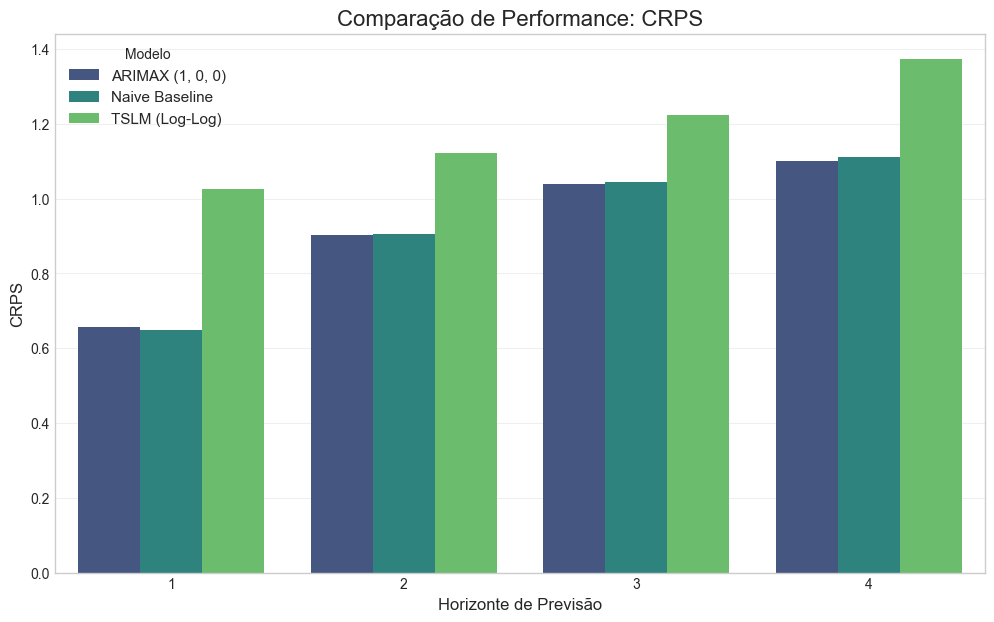

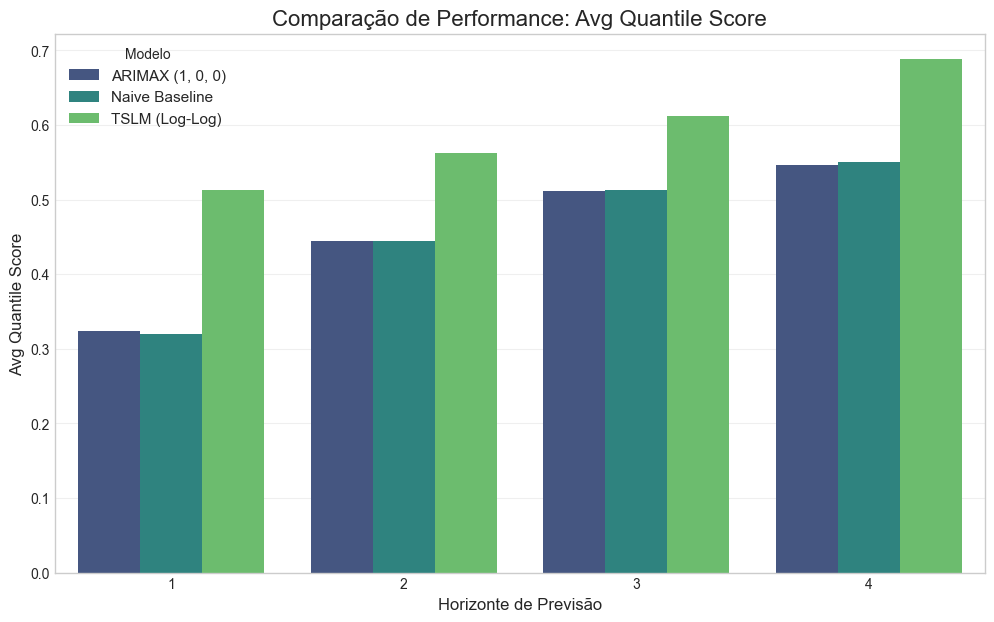

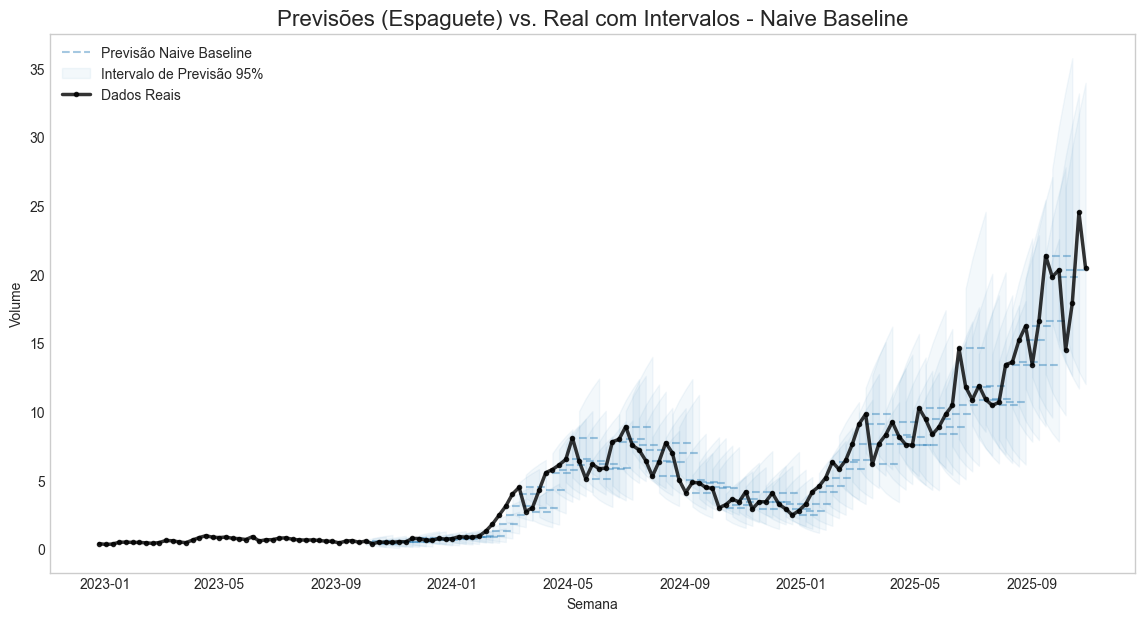

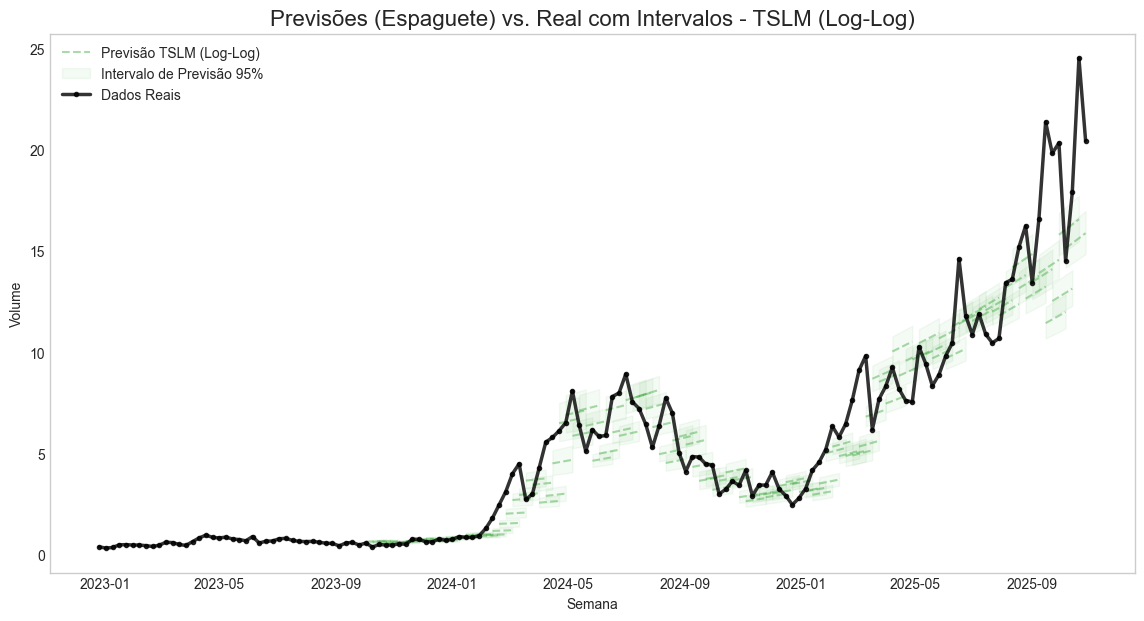

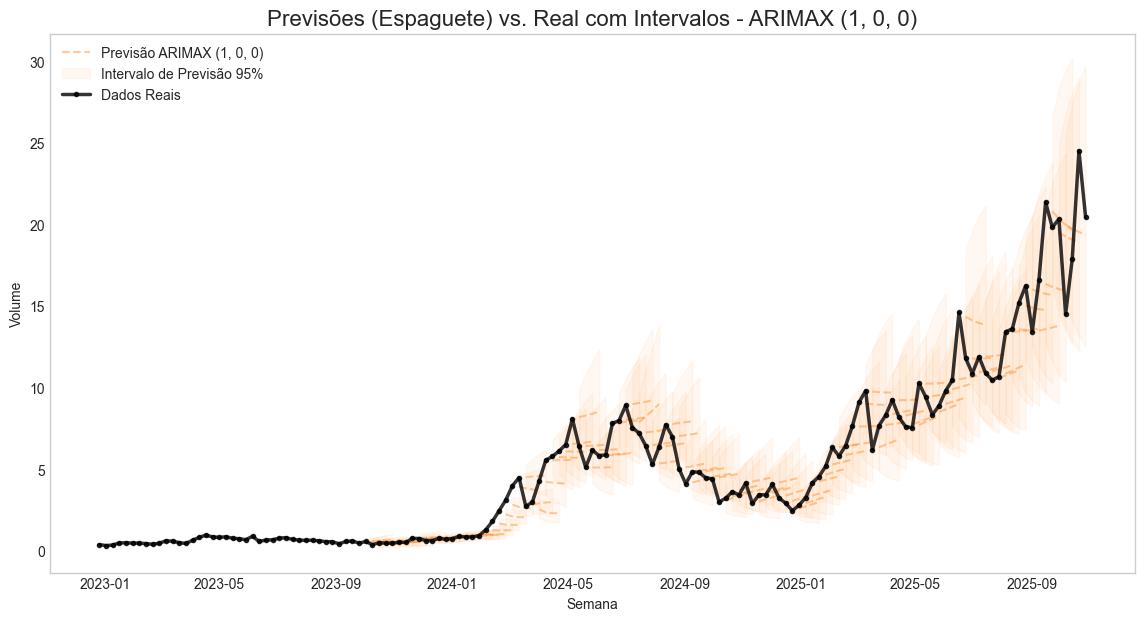

In [13]:
viz = ResultsVisualizer()
metrics_to_plot = [m.name for m in evaluator.metrics]

for metric in metrics_to_plot:
    viz.plot_metric_comparison(df_metrics[df_metrics['Horizon'] != 'Geral'], metric)

# Gráficos de previsão com intervalo
viz.plot_spaghetti_with_intervals(results_naive, df_processed, TARGET_COL)
viz.plot_spaghetti_with_intervals(results_tslm, df_processed, TARGET_COL)
viz.plot_spaghetti_with_intervals(results_arimax, df_processed, TARGET_COL)

In [26]:
df_metrics

,Model,Horizon,RMSE,MAE,Winkler Score (a=0.05),CRPS,Avg Quantile Score
0,"ARIMAX (1, 0, 0)",1,1.854940,1.346841,9.353217,0.959768,0.472944
1,"ARIMAX (1, 0, 0)",2,2.280051,1.745533,10.106652,1.241029,0.603780
2,"ARIMAX (1, 0, 0)",3,2.577781,2.027231,9.216894,1.414483,0.691101
3,"ARIMAX (1, 0, 0)",4,2.649982,1.984331,10.433054,1.451843,0.724591
12,"ARIMAX (1, 0, 0)",Geral,2.361503,1.775984,9.777454,1.266781,0.623104
4,Naive Baseline,1,1.914525,1.400476,9.097271,0.994244,0.490246
5,Naive Baseline,2,2.424536,1.881905,9.900259,1.334119,0.650100
6,Naive Baseline,3,2.754906,2.226667,9.913916,1.537450,0.754422
7,Naive Baseline,4,2.864886,2.224048,12.025186,1.631463,0.808886
13,Naive Baseline,Geral,2.516986,1.933274,10.234158,1.374319,0.675913
